# Weather Forecasting
### Forecasting future temperature, rainfall & humidity per district (2000–2025 → future)

We build and compare two forecasting approaches per district:

1. **Classical baseline** — SARIMA (seasonal ARIMA) on monthly-aggregated series, since Sri Lankan
   weather has a strong, stable annual seasonal cycle (2 monsoons).
2. **Deep learning** — an LSTM sequence-to-one model trained on all districts jointly (district as a
   categorical feature) to forecast the next `N` months of temperature, rainfall and humidity.

Both are evaluated with MAE / RMSE on a held-out final period, and the better model's forecasts are
exported for use by the ANN.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

RAW_DIR  = '../data/raw'
PROC_DIR = '../data/processed'
MODEL_DIR = '../models'

np.random.seed(42)


### Load & aggregate to monthly series per district

In [2]:
weather = pd.read_csv(f'{RAW_DIR}/Sri_Lanka_NASA_POWER_Weather_2000_2025.csv', parse_dates=['date'])
weather = weather.sort_values(['district', 'date'])

monthly = (weather
           .set_index('date')
           .groupby('district')
           .resample('MS')[['temperature_avg_c', 'rainfall_mm', 'humidity_percent']]
           .mean()
           .reset_index())

print(monthly.shape)
monthly.head()


(7800, 5)


,district,date,temperature_avg_c,rainfall_mm,humidity_percent
0,Ampara,2000-01-01,26.015161,0.968065,81.665806
1,Ampara,2000-02-01,26.651724,2.826552,79.834483
2,Ampara,2000-03-01,27.780968,0.964516,75.979355
3,Ampara,2000-04-01,29.377000,2.071000,72.113333
4,Ampara,2000-05-01,30.449355,1.122581,67.864194


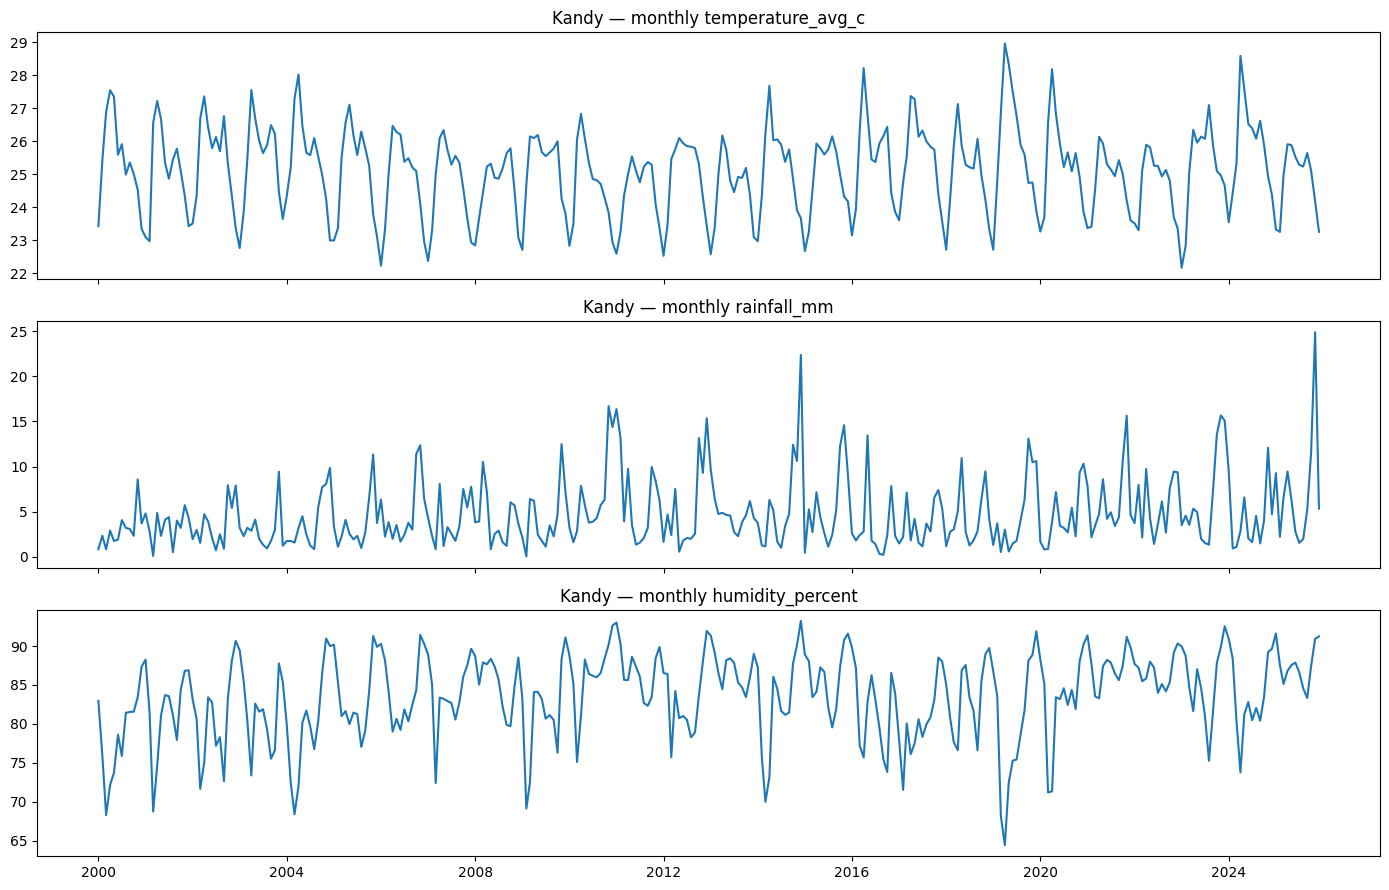

In [4]:
TARGET_DISTRICT = 'Kandy'
ts = monthly[monthly['district'] == TARGET_DISTRICT].set_index('date')[['temperature_avg_c','rainfall_mm','humidity_percent']]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, col in zip(axes, ts.columns):
    ax.plot(ts.index, ts[col])
    ax.set_title(f'{TARGET_DISTRICT} — monthly {col}')
plt.tight_layout()
plt.savefig('../outputs/notebooks_task3/01_monthly_series_example.png', dpi=120)
plt.show()


### Classical baseline: SARIMA per variable (example district)

In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_sarima_forecast(series, order=(1,1,1), seasonal_order=(1,1,1,12), n_forecast=12, n_test=12):
    train, test = series.iloc[:-n_test], series.iloc[-n_test:]
    model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                     enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    test_pred = fit.forecast(steps=n_test)
    future_fit = SARIMAX(series, order=order, seasonal_order=seasonal_order,
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    future_forecast = future_fit.forecast(steps=n_forecast)
    return test, test_pred, future_forecast

sarima_results = {}
for col in ['temperature_avg_c', 'rainfall_mm', 'humidity_percent']:
    test, test_pred, future = fit_sarima_forecast(ts[col])
    mae  = mean_absolute_error(test, test_pred)
    rmse = np.sqrt(mean_squared_error(test, test_pred))
    sarima_results[col] = {'test': test, 'test_pred': test_pred, 'future': future, 'mae': mae, 'rmse': rmse}
    print(f'{col:20s} SARIMA  MAE={mae:6.3f}  RMSE={rmse:6.3f}')


c:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, fr

temperature_avg_c    SARIMA  MAE= 0.855  RMSE= 0.913


c:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, fr

rainfall_mm          SARIMA  MAE= 3.278  RMSE= 4.825


c:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, fr

humidity_percent     SARIMA  MAE= 2.905  RMSE= 3.480


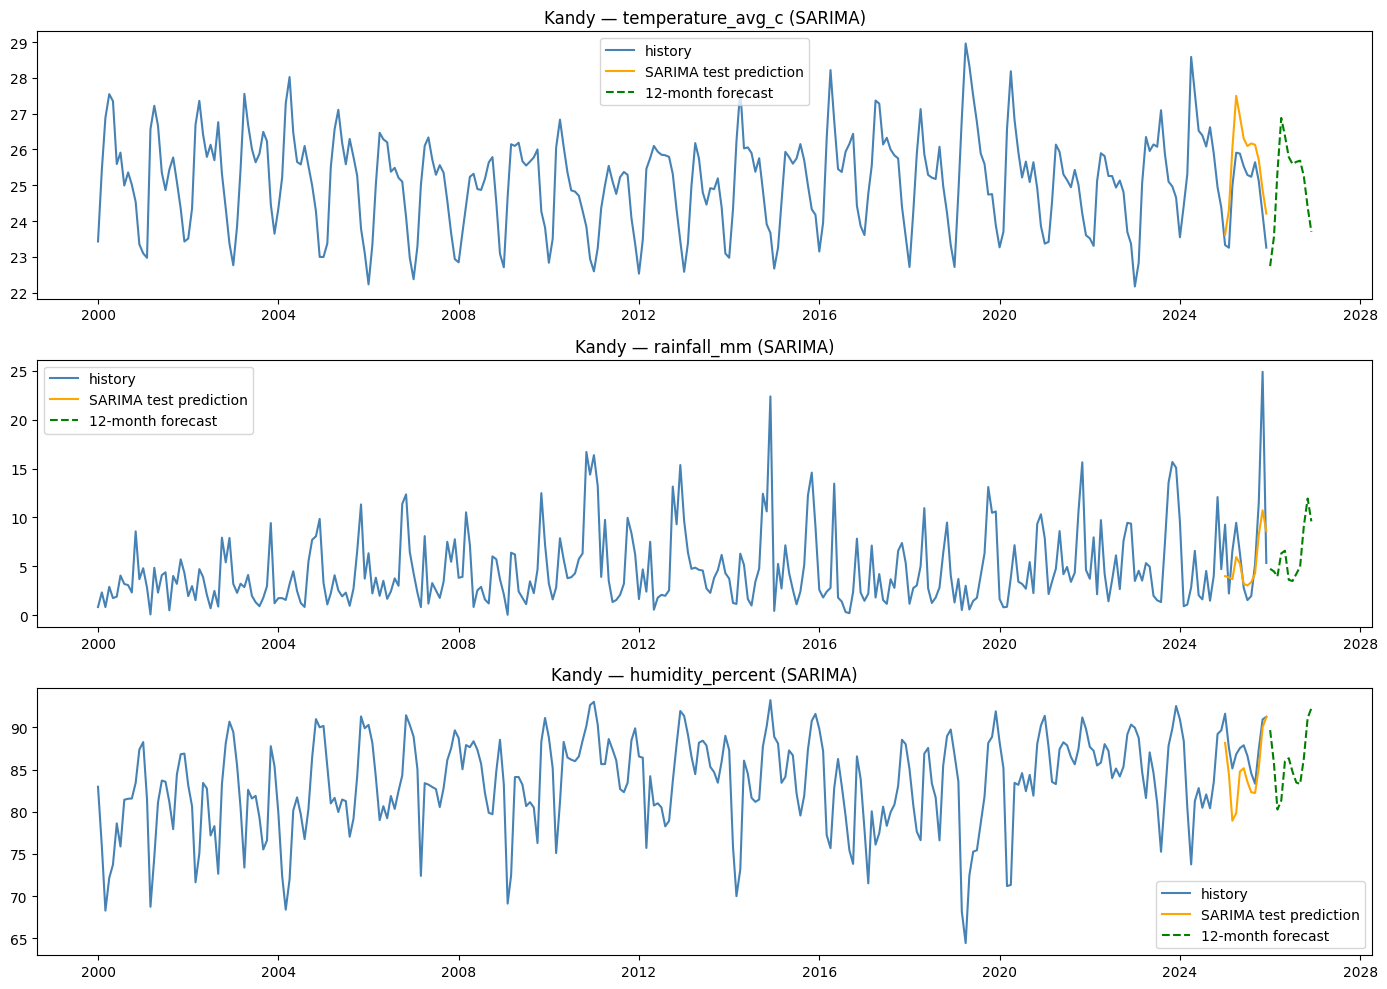

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, col in zip(axes, sarima_results):
    r = sarima_results[col]
    ax.plot(ts.index, ts[col], label='history', color='steelblue')
    ax.plot(r['test'].index, r['test_pred'], label='SARIMA test prediction', color='orange')
    future_index = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(1), periods=len(r['future']), freq='MS')
    ax.plot(future_index, r['future'].values, label='12-month forecast', color='green', linestyle='--')
    ax.set_title(f'{TARGET_DISTRICT} — {col} (SARIMA)')
    ax.legend()
plt.tight_layout()
plt.savefig('../outputs/notebooks_task3/02_sarima_forecast_example.png', dpi=120)
plt.show()


### Deep learning approach: multivariate LSTM across all districts

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

LOOKBACK   = 12 
TARGETS    = ['temperature_avg_c', 'rainfall_mm', 'humidity_percent']
HORIZON    = 12

districts = sorted(monthly['district'].unique())
district_to_id = {d: i for i, d in enumerate(districts)}
n_districts = len(districts)
print(f'{n_districts} districts')


25 districts


In [9]:
scalers = {}
monthly_scaled = monthly.copy()
for col in TARGETS:
    scaler = MinMaxScaler()
    monthly_scaled[col] = scaler.fit_transform(monthly[[col]])
    scalers[col] = scaler

joblib_dump_scalers_path = f'{MODEL_DIR}/weather_scalers.pkl'
import joblib
joblib.dump(scalers, joblib_dump_scalers_path)


['../models/weather_scalers.pkl']

In [10]:
def build_sequences(df, lookback=LOOKBACK):
    X, y, dist_ids = [], [], []
    for d in districts:
        sub = df[df['district'] == d].sort_values('date')
        arr = sub[TARGETS].values
        for i in range(len(arr) - lookback):
            X.append(arr[i:i+lookback])
            y.append(arr[i+lookback])
            dist_ids.append(district_to_id[d])
    return np.array(X), np.array(y), np.array(dist_ids)

X_seq, y_seq, dist_ids = build_sequences(monthly_scaled)
print('Sequences:', X_seq.shape, y_seq.shape, dist_ids.shape)


Sequences: (7500, 12, 3) (7500, 3) (7500,)


In [11]:
n_total_months = monthly_scaled['date'].nunique()
split_point = int(len(X_seq) * 0.85)

X_train_seq, X_test_seq = X_seq[:split_point], X_seq[split_point:]
y_train_seq, y_test_seq = y_seq[:split_point], y_seq[split_point:]
dist_train, dist_test   = dist_ids[:split_point], dist_ids[split_point:]

print(X_train_seq.shape, X_test_seq.shape)


(6375, 12, 3) (1125, 12, 3)


In [12]:
district_onehot_train = keras.utils.to_categorical(dist_train, num_classes=n_districts)
district_onehot_test  = keras.utils.to_categorical(dist_test, num_classes=n_districts)

seq_input  = keras.Input(shape=(LOOKBACK, len(TARGETS)), name='weather_sequence')
dist_input = keras.Input(shape=(n_districts,), name='district_onehot')

x = layers.LSTM(64, return_sequences=True)(seq_input)
x = layers.Dropout(0.2)(x)
x = layers.LSTM(32)(x)
x = layers.Concatenate()([x, dist_input])
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(len(TARGETS), activation='linear')(x)

lstm_model = keras.Model(inputs=[seq_input, dist_input], outputs=output, name='weather_lstm_forecaster')
lstm_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
lstm_model.summary()


Model: "weather_lstm_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ weather_sequence    │ (None, 12, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 12, 64)    │     17,408 │ weather_sequence… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 12, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ district_onehot     │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 57)        │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ district_onehot[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,856 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │         99 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 31,779 (124.14 KB)

 Trainable params: 31,779 (124.14 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history = lstm_model.fit(
    [X_train_seq, district_onehot_train], y_train_seq,
    validation_split=0.15,
    epochs=60,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)
print('Training complete. Final val_loss:', min(history.history['val_loss']))


Training complete. Final val_loss: 0.01977531798183918


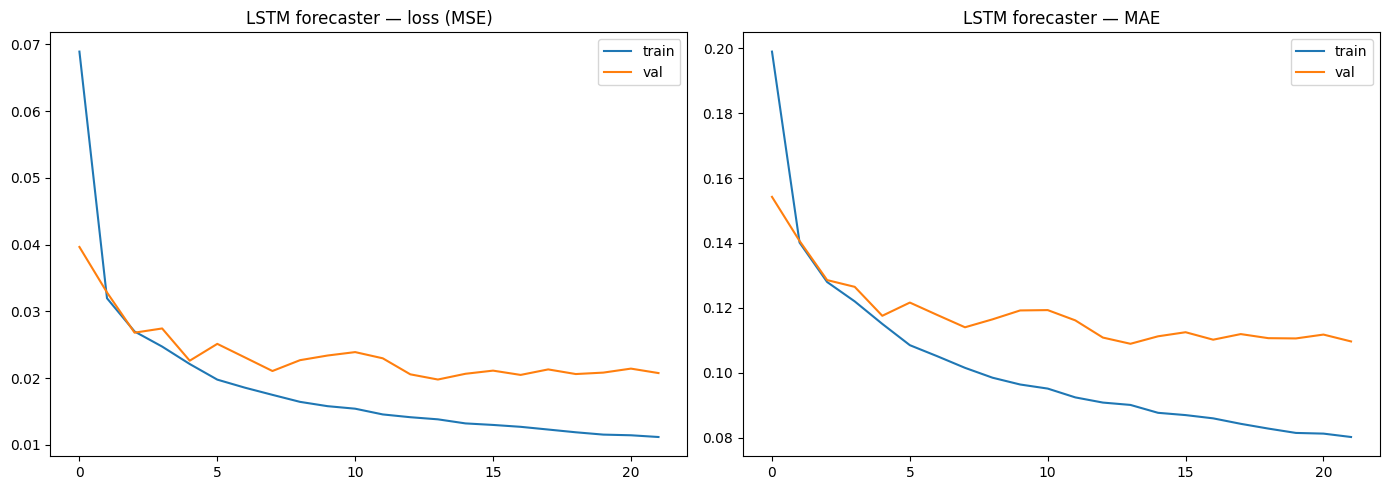

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('LSTM forecaster — loss (MSE)'); axes[0].legend()
axes[1].plot(history.history['mae'], label='train')
axes[1].plot(history.history['val_mae'], label='val')
axes[1].set_title('LSTM forecaster — MAE'); axes[1].legend()
plt.tight_layout()
plt.savefig('../outputs/notebooks_task3/03_lstm_training_curves.png', dpi=120)
plt.show()


### Evaluate the LSTM on the held-out test set (inverse-transformed to real units)

In [15]:
y_pred_scaled = lstm_model.predict([X_test_seq, district_onehot_test], verbose=0)

def inverse_all(arr_scaled):
    out = np.zeros_like(arr_scaled)
    for i, col in enumerate(TARGETS):
        out[:, i] = scalers[col].inverse_transform(arr_scaled[:, i].reshape(-1,1)).ravel()
    return out

y_pred = inverse_all(y_pred_scaled)
y_true = inverse_all(y_test_seq)

header = f"{'Variable':20s} {'MAE':>8s} {'RMSE':>8s}"
print(header)
lstm_scores = {}
for i, col in enumerate(TARGETS):
    mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    lstm_scores[col] = {'mae': mae, 'rmse': rmse}
    print(f'{col:20s} {mae:8.3f} {rmse:8.3f}')


Variable                  MAE     RMSE
temperature_avg_c       1.347    1.523
rainfall_mm             2.939    3.720
humidity_percent        3.758    4.610


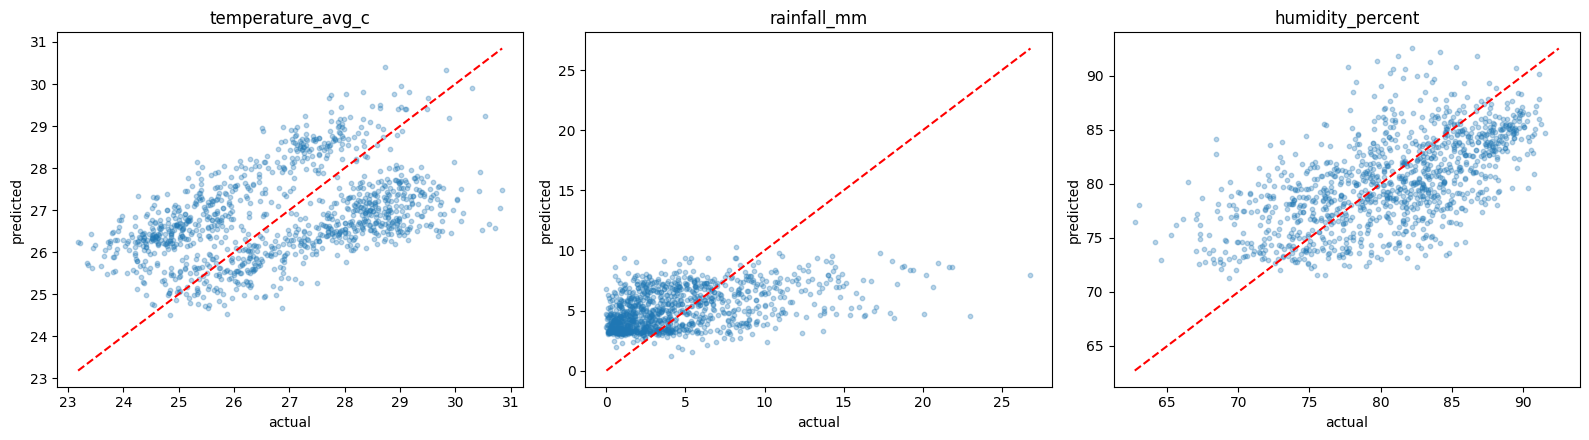

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
for ax, col in zip(axes, TARGETS):
    idx = list(TARGETS).index(col)
    ax.scatter(y_true[:, idx], y_pred[:, idx], alpha=0.3, s=10)
    lims = [min(y_true[:, idx].min(), y_pred[:, idx].min()), max(y_true[:, idx].max(), y_pred[:, idx].max())]
    ax.plot(lims, lims, 'r--')
    ax.set_xlabel('actual'); ax.set_ylabel('predicted'); ax.set_title(col)
plt.tight_layout()
plt.savefig('../outputs/notebooks_task3/04_lstm_actual_vs_predicted.png', dpi=120)
plt.show()


### Recursive forecasting: project every district forward 12 months

In [17]:
def forecast_district(district_name, n_months=12):
    sub = monthly_scaled[monthly_scaled['district'] == district_name].sort_values('date')
    window = sub[TARGETS].values[-LOOKBACK:].copy()
    d_onehot = keras.utils.to_categorical([district_to_id[district_name]], num_classes=n_districts)

    forecasts = []
    last_date = sub['date'].max()
    for step in range(n_months):
        pred_scaled = lstm_model.predict([window[np.newaxis, :, :], d_onehot], verbose=0)[0]
        forecasts.append(pred_scaled)
        window = np.vstack([window[1:], pred_scaled])

    forecasts = np.array(forecasts)
    forecasts_real = inverse_all(forecasts)
    future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=n_months, freq='MS')
    return pd.DataFrame(forecasts_real, columns=TARGETS, index=future_dates)

all_forecasts = {}
for d in districts:
    all_forecasts[d] = forecast_district(d, n_months=12)

print('Forecasted 12 months ahead for all', len(all_forecasts), 'districts')
all_forecasts[TARGET_DISTRICT]


Forecasted 12 months ahead for all 25 districts


,temperature_avg_c,rainfall_mm,humidity_percent
2026-01-01,23.965033,6.932240,90.635529
2026-02-01,24.316797,5.800395,88.464638
2026-03-01,24.819201,5.022993,86.055809
2026-04-01,25.105261,4.755107,84.694504
2026-05-01,25.265289,4.529537,83.823868
2026-06-01,25.428486,4.427078,83.193405
2026-07-01,25.624502,4.484774,82.749863
2026-08-01,25.749676,4.731415,82.565613
2026-09-01,25.703886,5.338100,82.878159
2026-10-01,25.301189,6.777737,84.685593


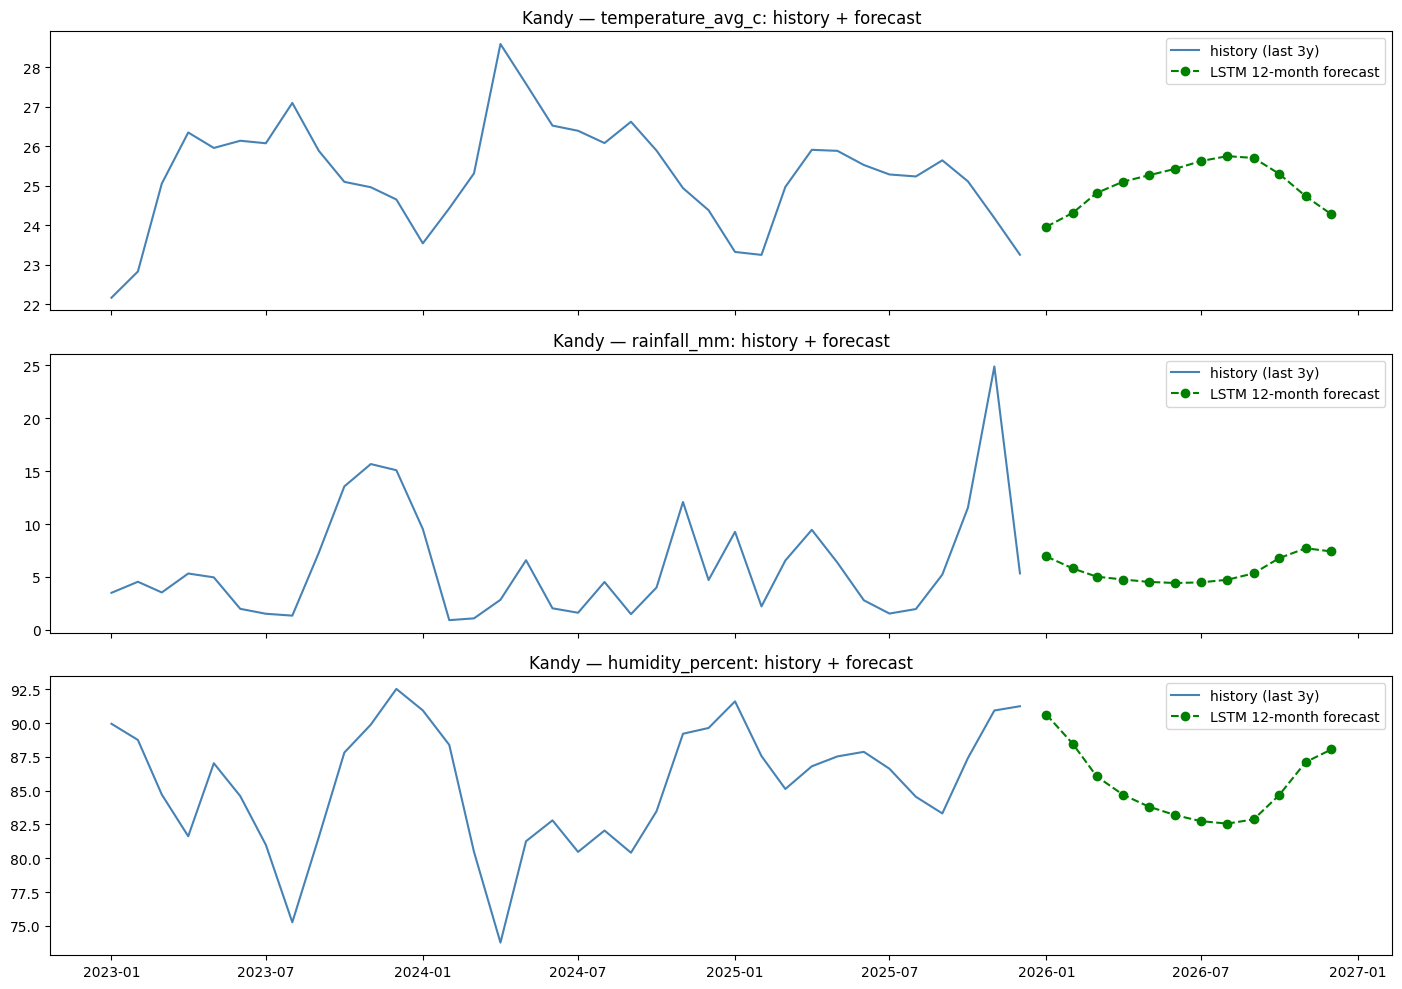

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
hist = monthly[monthly['district'] == TARGET_DISTRICT].set_index('date')
fc = all_forecasts[TARGET_DISTRICT]
for ax, col in zip(axes, TARGETS):
    ax.plot(hist.index[-36:], hist[col].iloc[-36:], label='history (last 3y)', color='steelblue')
    ax.plot(fc.index, fc[col], label='LSTM 12-month forecast', color='green', linestyle='--', marker='o')
    ax.set_title(f'{TARGET_DISTRICT} — {col}: history + forecast')
    ax.legend()
plt.tight_layout()
plt.savefig('../outputs/notebooks_task3/05_lstm_forecast_example.png', dpi=120)
plt.show()


In [19]:
forecast_long = []
for d, df in all_forecasts.items():
    tmp = df.copy()
    tmp['district'] = d
    tmp['forecast_month'] = np.arange(1, len(tmp)+1)
    forecast_long.append(tmp.reset_index().rename(columns={'index': 'date'}))
forecast_long = pd.concat(forecast_long, ignore_index=True)
forecast_long.to_csv(f'{PROC_DIR}/weather_forecast_12m.csv', index=False)
print('Saved forecasts ->', f'{PROC_DIR}/weather_forecast_12m.csv')
forecast_long.head()


Saved forecasts -> ../data/processed/weather_forecast_12m.csv


,date,temperature_avg_c,rainfall_mm,humidity_percent,district,forecast_month
0,2026-01-01,26.136759,7.441009,81.660172,Ampara,1
1,2026-02-01,26.417812,5.514103,78.856529,Ampara,2
2,2026-03-01,26.933172,4.554795,77.426308,Ampara,3
3,2026-04-01,27.533735,3.735097,76.149017,Ampara,4
4,2026-05-01,28.115816,2.943925,74.868073,Ampara,5


In [20]:
lstm_model.save(f'{MODEL_DIR}/weather_lstm_forecaster.keras')
print('Saved LSTM model ->', f'{MODEL_DIR}/weather_lstm_forecaster.keras')

Saved LSTM model -> ../models/weather_lstm_forecaster.keras
